# Stakeholder-Ready Analytical Report: Main Objective

### Generated by Dan Baldwin - Data Analyst for Shroomz_Madness, Inc. 

For the review of Plato P. Fuddwinkle IVth - Chief Data Officer of Shroomz_Madness, Inc.

The goal of this feasibility analysis to review the usage of different clustering model software for automated drones outfitted with FLIR cameras to search for, identify, and gather the mushroom 'Psilocybe Cubensis' autonomously. The three clustering methods to be evaluated will be:

1) KMeans
2) DBSCAN
3) MeanShift

The best clustering method will be selected for further trials including UAT deployment in the Olympic Peninsula of Washington. Each clustering tool will review an image of 'Psilocybe Cubensis' and be evaluated on how it pares down and isolates the image.

Included in this anlaysis will be a review of the initial dataset, consisting of a picture of 'Psilocybe Cubensis'. The image will be pre-processed, with data cleansed where appropriate. The relationship between all features will be examined, and analyzed to determine the most suitable model to refine in futher iterations towards the stated goal.

### DATA DESCRIPTION
Test image is of a set of mushrooms of one particular genus: 'Psilocybe Cubensis' that are found in the forests of the Pacific Northwest. The file is called 'Psilocybe.semilanceata.Alan', and it is a JPG file with a size of 17KB. The photo is representative of how such mushrooms would appar in the wild. 

# DATA EXPLORATION & PREPARATION

## Data Preparation

In [1]:
# Set up warnings

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


In [9]:
# Install opencv-python in Jupyter Notebook extension on VSC

%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Import initial libraries
import seaborn as sns, pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
import cv2 as cv
from sklearn.cluster import MeanShift, estimate_bandwidth, KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from mpl_toolkits import mplot3d
import math
from scipy.cluster import hierarchy
from PIL import Image
import string
print(np.__version__)


2.4.4


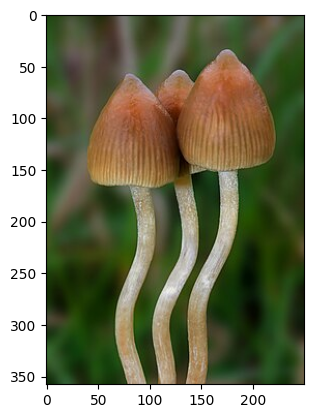

In [10]:
## Import data from hard drive
# location: ‘C:\Users\alter\Desktop\Coursera_Desktop\Final Projects\Final_Project 05_UnSup_Mach_learn_\Psilocybe.semilanceata.Alan.jpg’

# Fetch image

test_img = cv.imread(r'C:\Users\alter\Desktop\Coursera_Desktop\Final Projects\Final_Project 05_UnSup_Mach_learn_\Psilocybe.semilanceata.Alan.jpg')
plt.imshow(cv.cvtColor(test_img, cv.COLOR_BGR2RGB))
plt.show()


### Pre-processing the data image

In [11]:
# pre-process image

test_img = cv.cvtColor(test_img, cv.COLOR_BGR2RGB)

In [12]:
# shape to obtain the tuple of (height, width, channels).

test_img.shape


(358, 250, 3)

### Begin Exploratory Data Analysis (EDA) of the image's dataset
#### Convert the image to rows for each pixel, and 3 columns for each color channel (Red, Green, Blue) as a NumPy array of test_X:

In [13]:
# Reshape into an (N, 3) array where each row is [R, G, B]
test_X = test_img.reshape(-1,3)
print("shape: ",test_X.shape)
print("data type :", test_X.dtype)


shape:  (89500, 3)
data type : uint8


In [14]:
# Create a subsample of points to avoid freezing Matplotlib when plotting a 3D graph

shroom_num_samples = 3000
test_idx = np.random.choice(test_X.shape[0], size=shroom_num_samples, replace=False)
shroom_sampled_X = test_X[test_idx]


In [15]:
# Extracting channel coordinates from a 2D image for a 3D array

r = shroom_sampled_X[:, 0]
g = shroom_sampled_X[:, 1]
b = shroom_sampled_X[:, 2]


In [16]:
# Normalize color values between 0.0 and 1.0 for plotting
colors = shroom_sampled_X / 255.0


In [18]:
# Verifying the numerical datasets are present prior to conducting the clustering analysis.
print(shroom_sampled_X[:5])
print('Data type:', shroom_sampled_X.dtype)
print('Is numerical:', np.issubdtype(colors.dtype, np.number))



[[111 109  94]
 [ 80  74  26]
 [ 93  93  67]
 [ 20  56  12]
 [ 82  85  58]]
Data type: uint8
Is numerical: True


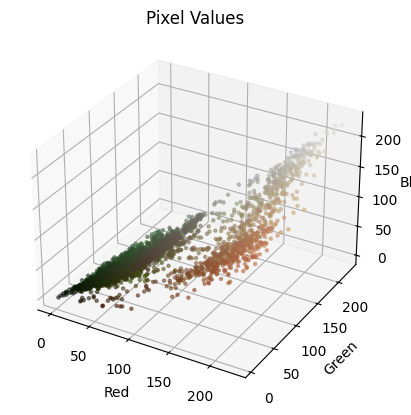

In [19]:
# Establish pixel values in a 3D scatter plot

ax = plt.axes(projection ="3d")
ax.scatter3D(r, g, b, c=colors, marker=".", alpha=0.5) 
ax.set_xlabel("Red") 
ax.set_ylabel("Green") 
ax.set_zlabel("Blue") 
ax.set_title("Pixel Values") 
plt.show() 


# CLUSTER ANALYSIS

## Performing THREE clustering model functions

### 1) KMeans
### 2) DBSCAN
### 3) MeanShift

In [20]:
# If the data type is anything other than float32, change it to float32
# NOTE: _MS corresponds to dataset being configured for Mean Shift
test_X_KM = np.float32(test_X)
test_X_DB = np.float32(test_X)
test_X_MS = np.float32(test_X)

### KMeans Clustering Review

In [21]:
# For a KMeans Clustering review, capture dimensions from original shape
h, w, c = test_img.shape


In [22]:
### Apply KMeans to the image

# Fit K-Means (e.g., reduce image to 8 colors)
k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
km_labels = kmeans.fit_predict(test_X_KM)

# Map each pixel to its cluster center and restore original shape
compressed_pixels = kmeans.cluster_centers_[km_labels]
quantized_img_np = compressed_pixels.reshape(h, w, c).astype(np.uint8)

# Save or display the quantized image
quantized_img = Image.fromarray(quantized_img_np)
quantized_img.save("quantized_output.jpg")


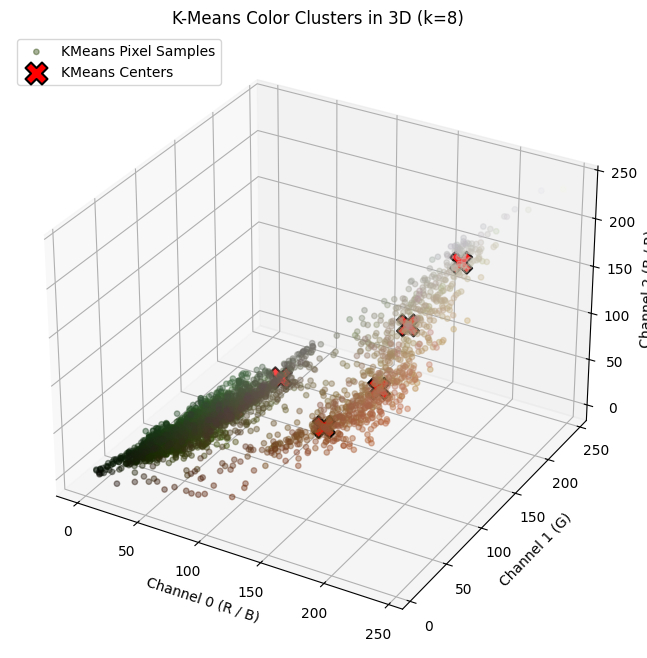

In [57]:
# Displaying the KMeans clusters via a 3D scatter of pixel samples with cluster centers overlaid

np.random.seed(42)
sample_size = 3000
idx = np.random.choice(test_X.shape[0], size=sample_size, replace=False)

# Match the dtype
KM_sample_pixels = test_X[idx].astype(kmeans.cluster_centers_.dtype)

# 2. Predict cluster assignments for the sampled pixels
km_labels = kmeans.predict(KM_sample_pixels)

# 3. Retrieve cluster centers and normalize colors for Matplotlib [0, 1]
centers = kmeans.cluster_centers_
point_colors = KM_sample_pixels / 255.0


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")

# Scatter sample pixels colored by their actual RGB values
ax.scatter(
    sample_pixels[:, 0],
    sample_pixels[:, 1],
    sample_pixels[:, 2],
    c=point_colors,
    marker="o",
    s=15,
    alpha=0.4,
    label="KMeans Pixel Samples",
)

# Plot KMeans cluster centers as prominent red markers
ax.scatter(
    centers[:, 0],
    centers[:, 1],
    centers[:, 2],
    c="red",
    marker="X",
    s=250,
    edgecolor="black",
    linewidth=1.5,
    label="KMeans Centers",
)

ax.set_title(f"K-Means Color Clusters in 3D (k={kmeans.n_clusters})")
ax.set_xlabel("Channel 0 (R / B)")
ax.set_ylabel("Channel 1 (G)")
ax.set_zlabel("Channel 2 (B / R)")
ax.legend(loc="upper left")

plt.show()

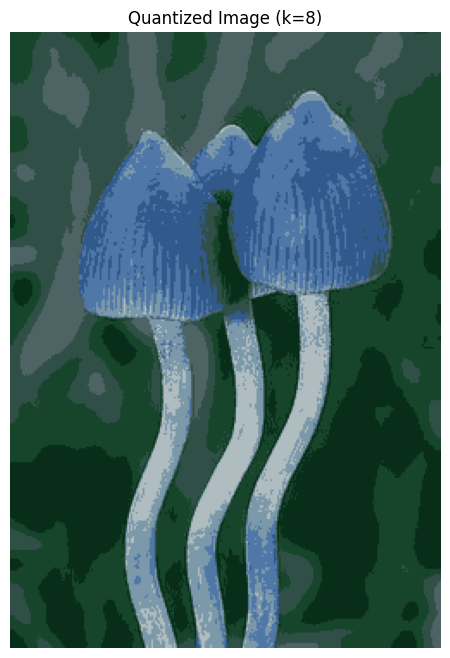

In [24]:
# Showing the image after KMeans has been applied.
plt.figure(figsize=(6, 8))
plt.imshow(cv.cvtColor(quantized_img_np, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Quantized Image (k={k})")
plt.show()

### DBSCAN CLUSTERING REVIEW

In [26]:
# Set up a random subsample; reminder, shroom_num_samples = 3000

np.random.seed(42)
idx_DBS = np.random.choice(test_X_DB.shape[0], size=shroom_num_samples, replace=False)
shroom_subsampleDBS = test_X_DB[idx_DBS]


In [31]:
# Fit DBSCAN on the subsample

shroom_ClusterDBS = DBSCAN(eps=8, min_samples=10)
labels_DBS = shroom_ClusterDBS.fit_predict(shroom_subsampleDBS)

# Report cluster and house counts
n_clustersDBS = len(set(labels_DBS) - {-1})
n_noiseDBS = np.sum(labels_DBS) == -1
print(f'DBSCAN found {n_clustersDBS} clusters and {n_noiseDBS} points of noise')


DBSCAN found 3 clusters and False points of noise


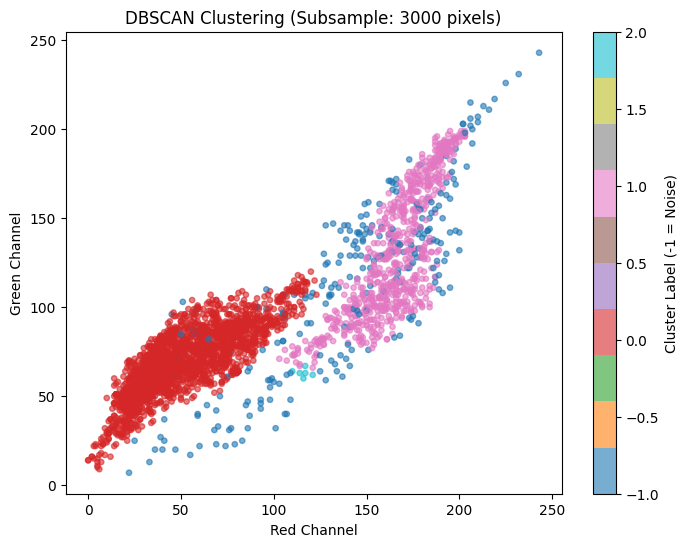

In [33]:
# Plot 2D scatter of the sampled pixels 

plt.figure(figsize=(8, 6)) 
scatter = plt.scatter( 
       shroom_subsampleDBS[:, 0], 
       shroom_subsampleDBS[:, 1], 
       c=labels_DBS,
       cmap="tab10", 
       s=15, 
       alpha=0.6, 
) 
plt.colorbar(scatter, label="Cluster Label (-1 = Noise)") 
plt.xlabel("Red Channel") 
plt.ylabel("Green Channel") 
plt.title(f"DBSCAN Clustering (Subsample: {shroom_subsampleDBS.shape[0]} pixels)")
plt.show() 


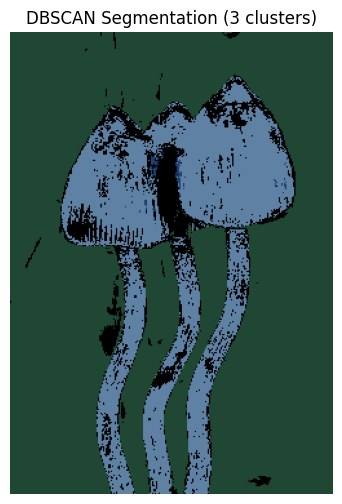

In [50]:
# Plotting the reconstituted DBSCAN results as an image.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(shroom_subsampleDBS, labels_DBS)
full_labels_DBS = knn.predict(test_X_DB)

# 2. Create an empty canvas and assign cluster average colors
reconstructed_pixels = np.zeros_like(test_X_DB, dtype=np.uint8)
unique_labels = np.unique(full_labels_DBS)

for label in unique_labels:
    if label == -1:
        reconstructed_pixels[full_labels_DBS == -1] = [0, 0, 0]  # Black for noise
    else:
        mean_color = test_X_DB[full_labels_DBS == label].mean(axis=0).astype(np.uint8)
        reconstructed_pixels[full_labels_DBS == label] = mean_color

# 3. Reshape the pixel array and display
result_DBS = reconstructed_pixels.reshape(test_img.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(result_DBS, cv.COLOR_BGR2RGB))
plt.title(f"DBSCAN Segmentation ({n_clustersDBS} clusters)")
plt.axis("off")
plt.show()

### MeanShift Clustering Review

In [34]:
# Estimate bandwidth to use with the MeanShift algorithm, using the estimate_bandwidth function:
bandwidth_MS = estimate_bandwidth(test_X_MS, quantile=.06, n_samples=3000)
bandwidth_MS


np.float64(21.24582714164592)

In [36]:
# Create a MeanShift Object in sklearn and fit the model
subsample_MS_idx = np.random.choice(test_X_MS.shape[0], size=3000, replace=False)
shroom_MS = MeanShift(bandwidth=bandwidth_MS,bin_seeding=True)
shroom_MS.fit(test_X_MS[subsample_MS_idx])


,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(21.24582714164592)
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary <n_jobs>` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers.","ndarray[float32](9, 3)","[[ 35.26, 61.41, 16.11], [ 73.38, 80.13, 51.19], [159.8 ,107.83, 66.8 ], ..., [199.3 ,196.49,186.78], [ 63.11, 28.78, 5.33], [235. ,236. ,231. ]]"
"labels_ labels_: ndarray of shape (n_samples,)Labels of each point.","ndarray[int64](3000,)","[2,2,1,...,4,1,0]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3


In [37]:
# Predict cluster labels for all pixels in the full image

labeled_MS=shroom_MS.predict(test_X_MS)


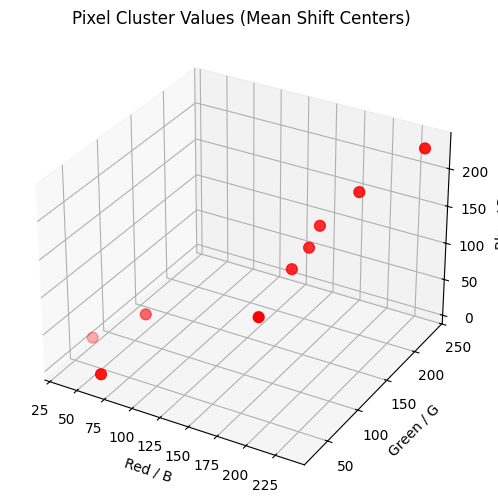

In [42]:
# Convert the clusters <<DATATYPE>> datatype for images
cluster_uint8_MS = np.uint8(shroom_MS.cluster_centers_)

# Plot 3D Cluster Centers 
fig = plt.figure(figsize=(8, 6)) 
ax = fig.add_subplot(projection="3d") 
ax.set_title("Pixel Cluster Values (Mean Shift Centers)") 
ax.scatter3D( cluster_uint8_MS[:, 0], cluster_uint8_MS[:, 1], cluster_uint8_MS[:, 2], color="red", s=60, ) 
ax.set_xlabel("Red / B") 
ax.set_ylabel("Green / G") 
ax.set_zlabel("Blue / R") 
plt.show()


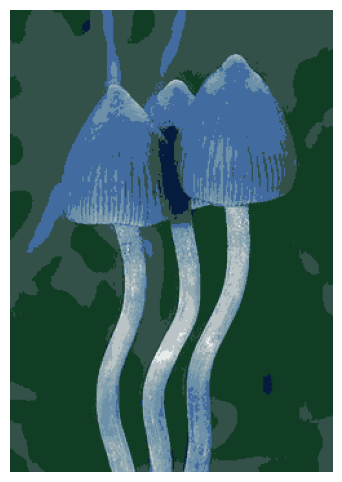

In [44]:
# Map each pixel to its cluster center (vectorized and avoids slow for-loops)

result_MS = cluster_uint8_MS[labeled_MS]
result_MS = result_MS.reshape(test_img.shape)

# Display the segmented image
plt.figure(figsize=(8, 6)) 
plt.imshow(cv.cvtColor(result_MS, cv.COLOR_BGR2RGB)) 
plt.axis("off") 
plt.show() 


# MODEL SELECTION AND JUSTIFICATION

## Select the best performing model based on the results above.

Upon reviewing the three options above, the following considerations were applied:

1) Can the KNN Clustering method pare down the image to its core components for visual comparison against a sample photograph?
2) Can the DBSCAN pare down the image to its core components for visual comparison against a sample photograph?
3) Can the Mean Shift pare down the image to its core components for visual comparison against a sample photograph? 

Based on the evaluations above, the DBSCAN did the best job of identifying the different clusters of RGB colors, but the KMeans Cluster was able to assemble the best, most visually interpretable image, followed by the Mean Shift. In evaluating the interpretability and readability of both the 3D plots of the relevant clusters and of reassembling an image after model rendering, the KMeans outperformed the DBSCAN and the Mean Shift. Although it should be noted that the Mean Shift did a respectable job in comparison to the DBSCAN.

# KEY FINDINGS AND INSIGHTS

## Summarizing the Key insights from the selected model:

### Important Features: 
Both the KMeans and Mean Shift were less computer-resource intensive when building the models and then fitting them to the sample data. This is important when considering the limited amount of memory that each automated drone will have, plus transmission bandwidth for transmitting the visual images back to the core processing center. 

### Prediction Patterns:
DBSCAN and KMeans had superior prediction capabilities to Mean Shift based on the 3D plotting. Mean Shift didn't provide enough data to assure consistent prediction. The graphic clustering in DBSCAN and KMeans were interpretable to human users if flagged for review. 

### Classification Outcomes:
KMeans had the better overall capabilities in prediction and identification based on model performance. The 3D plotting to recognize colors and reconstituting the photo in order to provide effective visual images to human reviewers is superior to DBSCAN and Mean Shift. Classification outcomes must ultimate pass human review, and clear photos of identified mushrooms is critical; being able to use limited onboard memory and bandwidth to generate and transmit those photos is of utmost concern. 

## KEY FINDINGS
For concern of limited onboard memory and bandwidth transmission in autonomous drones, the KMeans model appears to be the most promising. However, there may be an argument for utilizing the DBSCAN cluster review as an initial check, and then followed up with a secondary KMeans model review in order to account for potential Type I and II errors.

#LIMITATIONS AND FUTURE WORK

### Limitations

The first concern is making sure the code is set up to execute 3D plots properly if Matplotlib is being utilized. 3D plotting can be exceptionally memory-intensive, so care must be taken to ensure that the code is written correctly to pre-process and select sample images for review and 3D plotting. Onboard memory is limited and memory glitches or excessively large datasets could risk paralizing the autonomous drones if attempting 3D plotting on too-large of a dataset.

This is also a concern when conducting EDA on the results--incorrect 3D plotting will lock up a laptop due to all available memory being allocated to creating a 3D plot. 

Photos will have to be in a jpg format and then memory will have to be allocated for storage of the photos, along with memory allocation for application of the selected models. 

### Next Steps (FUTURE WORK)

Further analysis will need to be done to consider if two models can be utilized by the drones. The DBSCAN cluster analysis is superior to the KMeans--perhaps the two models can be used in sequential order to prevent Type 1 and Type 2 errors. A DBSCAN cluster analysis can be used initially, and then if the resulting data indicates the presence of the correct mushroom, then KMeans can be used as a subsequent check and analysis. 